# Simple Linear Regression for Factor Investing: Estimating a Stock's Market Beta

## Introduction

A key question in quantitative finance is how much of a stock's return can be explained by movements in the broader market. Are returns mainly driven by systematic market risk, or are they dominated by company-specific factors?

Linear regression provides a statistical framework for studying this relationship. In empirical asset pricing, regression models are used to estimate a security's exposure to risk factors, measure abnormal returns, and evaluate how well systematic factors explain asset returns.

The Capital Asset Pricing Model (CAPM), developed independently by Sharpe (1964) and Lintner (1965), is the simplest example of a factor model. It assumes that an asset's excess return can be explained by a single factor: the excess return of the market portfolio.

Although later research introduced additional factors—most notably the Fama and French (1993) three-factor model—the CAPM remains the starting point for understanding factor investing. It provides the foundation for estimating factor exposures and interpreting regression outputs in asset pricing models.

In this notebook, we estimate the **market beta (β)** of **Apple Inc. (AAPL)** using **Ordinary Least Squares (OLS) simple linear regression**. Instead of using simulated data, we work with historical market data and follow an empirical workflow commonly used in quantitative finance.

The analysis follows these steps:

* Collect historical price data.
* Calculate stock returns and market excess returns.
* Prepare and clean the regression dataset.
* Analyze the relationship between stock and market returns.
* Estimate the CAPM regression using OLS.
* Interpret the regression coefficients and evaluate model fit.

The focus is not only on estimating beta, but also on understanding the economic meaning of the regression outputs. We will examine:

* **Alpha (α):** the estimated return unexplained by the market factor.
* **Beta (β):** the sensitivity of the stock's excess return to market movements.
* **Residuals (ε):** the portion of returns not explained by the model.
* **R²:** the proportion of return variation explained by the market factor.

This notebook covers a single-factor model. Later notebooks will extend the same regression framework to multifactor models, including the **Fama–French Three-Factor Model**, the **Carhart Four-Factor Model**, and the **Fama–French Five-Factor Model**.

The methodology follows the standard approach used in empirical asset pricing research, where factor exposures are estimated through Ordinary Least Squares regression on historical excess returns.

---

## Learning Objectives

After completing this notebook, you will be able to:

* Explain why asset pricing models use excess returns instead of raw returns.
* Understand the role of linear regression in empirical finance.
* Prepare financial data for factor regression analysis.
* Estimate a CAPM regression using Ordinary Least Squares (OLS).
* Interpret alpha, beta, residuals, and R² in an asset pricing context.
* Evaluate how much of a stock's return variation is explained by market movements.
* Understand the limitations of single-factor models and why multifactor models were developed.
* Build the statistical foundation required for studying Fama–French and Carhart factor models.

---

## Notebook Roadmap

1. Setup & Imports
2. Data Collection
3. Building the Regression Dataset
4. Exploratory Data Analysis
5. From Scatterplot to Regression Line — The Theory
6. Estimating β via OLS
7. Interpreting the Regression Output
8. Model Diagnostics
9. Time-Series Stability: Rolling Beta Analysis
10. The CAPM Security Market Line
11. Takeaways & Next Steps

## 1. Setup & Imports

We begin by importing the libraries used throughout the notebook:

- **yfinance** — downloads historical stock price data directly from Yahoo Finance.
- **pandas_datareader** — downloads the Fama–French factor data hosted at Ken French's Data Library, including the market factor (`Mkt-RF`) and the risk-free rate (`RF`) used to compute excess returns.
- **statsmodels** — fits the Ordinary Least Squares (OLS) regression and produces the diagnostic summary table (standard errors, t-statistics, p-values, R²) used throughout Sections 6–7.
- **matplotlib** / **seaborn** / **scipy.stats** — visualization, including the normal Q-Q plot used in Section 8.

We also fix a common `start_date` so that both data sources cover the same historical window.

In [1]:
!pip install yfinance -q

import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

start_date = '1980-01-01'

/bin/bash: line 1: pip: command not found


ModuleNotFoundError: No module named 'matplotlib'

## 2. Data Collection

To estimate AAPL's market beta we need two monthly time series covering the same period: the stock's own returns, and the ingredients needed to compute *excess* returns — the market factor and the risk-free rate. We collect these from two independent sources and merge them by month.

### 2.1 Fama–French market factor

The CAPM reference defines an asset's excess return as its total return net of the risk-free rate over the same period. Its central claim is specifically about the residual component of this excess return — the part unexplained by beta — that its expected value is zero. To compute AAPL's excess return we need the risk-free rate, and to compute the market's excess return we need both the market return and the risk-free rate.

Conveniently, Kenneth French's data library already publishes both pieces as separate monthly columns: `Mkt-RF` (the market's excess return) and `RF` (the risk-free rate). We download this via `pandas_datareader`.

In [ ]:
print("Downloading Fama-French risk factors...")
ff_dict = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date)
ff_monthly = ff_dict[0].copy()

# The Fama-French index is a pandas Period type; converting it to a
# 'YYYY-MM' string makes it simple to merge with the AAPL data later.
ff_monthly.index = ff_monthly.index.strftime('%Y-%m')

print(f"Factors downloaded: {ff_monthly.shape[0]} months")
print("Available columns:", ff_monthly.columns.tolist())
ff_monthly.head()

Factors downloaded: 557 months
Available columns: ['Mkt-RF', 'SMB', 'HML', 'RF']


,Mkt-RF,SMB,HML,RF
Date,,,,
1980-01,5.50,1.62,1.85,0.80
1980-02,-1.23,-1.86,0.59,0.89
1980-03,-12.90,-6.70,-0.96,1.21
1980-04,3.95,1.05,1.03,1.26
1980-05,5.26,2.05,0.38,0.81


The Fama-French dataset downloaded above contains the foundational factors used in modern asset pricing:

* **Mkt-RF**: The market risk premium, representing the excess return of the broad market over the risk-free rate.
* **RF**: The risk-free rate, typically based on short-term U.S. Treasury bills.
* **SMB (Small Minus Big)**: The size factor, capturing the historical excess return of small-cap companies over large-cap companies.
* **HML (High Minus Low)**: The value factor, representing the historical excess return of value stocks (high book-to-market ratio) over growth stocks (low book-to-market ratio).

Explicitly, while `SMB` and `HML` are present in our merged dataset, this specific notebook will only utilize `Mkt-RF` and `RF` to evaluate the single-factor CAPM. We are reserving the size and value factors for future multifactor analysis.

### 2.2 Apple stock prices

Next we download AAPL's price history. We request `interval='1mo'` so the data lines up with the monthly frequency of the Fama–French factors — mixing frequencies (e.g., daily stock returns with monthly factors) would make the merge meaningless. This mirrors the setup in the CAPM reference's own example, which uses 60 months of American Express data to estimate a historical beta (Ch. 2, Table 2.1).

In [ ]:
print("Downloading AAPL monthly prices...")
apple = yf.download('AAPL', start=start_date, interval='1mo')
apple.head()

/tmp/ipykernel_469/1851562462.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download('AAPL', start=start_date, interval='1mo')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
1985-01-01,0.099061,0.106320,0.095218,0.099488,6366416000
1985-02-01,0.084544,0.105039,0.084544,0.099061,4733388800
1985-03-01,0.075577,0.088813,0.070880,0.084544,4615587200
1985-04-01,0.072588,0.078566,0.067037,0.075577,2868028800
1985-05-01,0.059351,0.076004,0.057643,0.072588,4639129600


### 2.3 Handling yfinance's column format

Depending on the installed version, `yfinance` can return either plain column names (`Close`) or a `MultiIndex` (e.g. `('Close', 'AAPL')`), even for a single ticker. The cell below flattens the columns if needed and then locates whichever column holds the closing price, so the rest of the notebook doesn't depend on a specific `yfinance` version.

In [ ]:
# Flatten a MultiIndex column structure if yfinance returned one.
if isinstance(apple.columns, pd.MultiIndex):
    apple.columns = ['_'.join(col).strip() for col in apple.columns.values]

# Find whichever column holds the closing price.
close_col = next((c for c in apple.columns if 'Close' in c), None)
if close_col is None:
    raise KeyError("No closing-price column found in the downloaded data.")
print(f"Using column '{close_col}' to compute returns.")

# Monthly return in percent, matching the units of the Fama-French factors.
apple['Return'] = apple[close_col].pct_change() * 100
apple['DateStr'] = apple.index.strftime('%Y-%m')

print(f"AAPL data ready: {apple.shape[0]} months")
apple[[close_col, 'Return']].head()

Using column 'Close_AAPL' to compute returns.
AAPL data ready: 499 months


,Close_AAPL,Return
Date,,
1985-01-01,0.099061,NaN
1985-02-01,0.084544,-14.655030
1985-03-01,0.075577,-10.606287
1985-04-01,0.072588,-3.954565
1985-05-01,0.059351,-18.235216


## 3. Building the Regression Dataset

We now merge the two sources on the `YYYY-MM` string and compute AAPL's excess return:

$$ \text{AAPL\_EXCESS} = \text{Return} - RF $$

which is exactly the left-hand side of the CAPM regression $R_i - R_f = \alpha + \beta(R_m - R_f) + \varepsilon$ that we estimate in Section 6.

In [ ]:
apple_clean = apple[['DateStr', 'Return']].copy()

merged = pd.merge(
    apple_clean,
    ff_monthly[['Mkt-RF', 'RF']],
    left_on='DateStr',
    right_index=True,
    how='inner'
)

print(f"Merged dataset: {merged.shape[0]} overlapping months")
merged.head()

Merged dataset: 497 overlapping months


,DateStr,Return,Mkt-RF,RF
Date,,,,
1985-01-01,1985-01,NaN,7.97,0.65
1985-02-01,1985-02,-14.655030,1.22,0.58
1985-03-01,1985-03,-10.606287,-0.83,0.62
1985-04-01,1985-04,-3.954565,-0.96,0.72
1985-05-01,1985-05,-18.235216,5.07,0.66


In [ ]:
merged['AAPL_EXCESS'] = merged['Return'] - merged['RF']
merged_clean = merged.dropna().reset_index(drop=True)

print(f"Final dataset ready for regression: {merged_clean.shape[0]} observations")
merged_clean.describe()

Final dataset ready for regression: 496 observations


,Return,Mkt-RF,RF,AAPL_EXCESS
count,496.000000,496.000000,496.000000,496.000000
mean,2.371959,0.772702,0.262823,2.109136
std,11.990203,4.478270,0.207444,12.000567
min,-57.743647,-23.190000,0.000000,-58.253647
25%,-4.283310,-1.905000,0.030000,-4.689475
50%,2.515679,1.220000,0.280000,2.260659
75%,9.648768,3.527500,0.430000,9.412897
max,45.378249,13.600000,0.790000,44.838249


## 4. Exploratory Data Analysis

Before fitting any model, it's good practice to look directly at the variables involved — OpenIntro's regression chapter builds its examples by first visualizing the two variables together, before ever fitting a line (Ch. 7.1). We start with a time-series view of both return series, then move to the joint scatterplot the regression itself is based on.

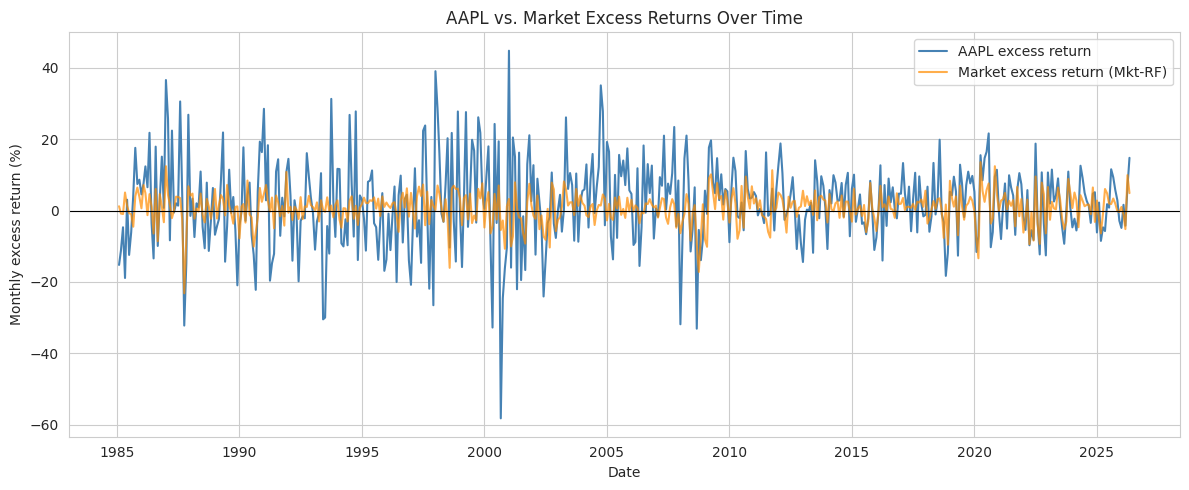

In [ ]:
dates = pd.to_datetime(merged_clean['DateStr'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, merged_clean['AAPL_EXCESS'], label='AAPL excess return', color='steelblue')
ax.plot(dates, merged_clean['Mkt-RF'], label='Market excess return (Mkt-RF)', color='darkorange', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Monthly excess return (%)')
ax.set_title('AAPL vs. Market Excess Returns Over Time')
ax.legend()
plt.tight_layout()
plt.show()

**Figure 1.** Monthly excess returns for AAPL and the overall market. AAPL tends to swing further in both directions than the market — an early visual hint that its beta will turn out to be above 1, which we confirm formally in Section 6.

## 5. From Scatterplot to Regression Line — The Theory

With the data ready, we pause on the theory before running any regression, so the coefficients in Section 6 have a clear meaning attached to them.

### 5.1 The general regression line

In general, simple linear regression fits a straight line through two numerical variables $x$ and $y$:

$$ y = b_0 + b_1 x + e $$

where $b_0$ and $b_1$ are the intercept and slope, and $e$ is the error for each observation (OpenIntro, Ch. 7.1). These coefficients aren't guessed — they're the values that minimize the sum of squared residuals, i.e., the vertical distances between each observed point and the line. This is what "Ordinary Least Squares" (OLS) means, and it's exactly what `statsmodels.OLS` does for us in Section 6.

### 5.2 The CAPM version of the same line

The CAPM reference writes the identical regression with finance-specific notation, regressing a portfolio's excess return on the market's excess return (Ch. 2, eq. 2.2):

$$ R_i - R_f = \alpha + \beta (R_m - R_f) + \varepsilon $$

Matching terms to the general form above: $\alpha$ plays the role of $b_0$, and $\beta$ plays the role of $b_1$. Two things make this more than "just a regression":

- **β is defined independently of the regression**, as the ratio of the covariance between the asset's and the market's returns to the variance of the market's return: $\beta_P = \text{Cov}(r_P, r_M) / \text{Var}(r_M)$ (eq. 2.1). The OLS slope happens to be the sample estimate of exactly this quantity — which is why running a regression is the standard way to *estimate* beta, even though beta is conceptually a forward-looking forecast, not merely a regression artifact.
- **The CAPM makes a specific claim about α**: that its expected value is zero for every stock and portfolio. Under CAPM, expected excess return is explained *entirely* by β — there's no room, on average, for stock-specific outperformance. A statistically significant, nonzero α in our results below would be evidence against that claim for AAPL over this sample.

## 6. Estimating β via OLS

We now fit the regression using `statsmodels`, mirroring eq. (2.2) directly: `Mkt-RF` is the single regressor, `sm.add_constant` adds the intercept term (α), and `AAPL_EXCESS` is the response.

In [ ]:
Y = merged_clean['AAPL_EXCESS']
X = sm.add_constant(merged_clean['Mkt-RF'])
capm_model = sm.OLS(Y, X).fit()

In [ ]:
print("=" * 60)
print("CAPM REGRESSION SUMMARY — AAPL vs. Market")
print("=" * 60)
print(capm_model.summary())

CAPM REGRESSION SUMMARY — AAPL vs. Market
                            OLS Regression Results                            
Dep. Variable:            AAPL_EXCESS   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     153.8
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           6.26e-31
Time:                        01:21:41   Log-Likelihood:                -1868.6
No. Observations:                 496   AIC:                             3741.
Df Residuals:                     494   BIC:                             3750.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

## 7. Interpreting the Regression Output

The `summary()` table above packs in everything needed to understand the stock's risk profile and performance. Using the exact values from our OLS summary, we can explain the economics of AAPL:

* **Beta (Mkt-RF Coefficient = 1.3056)**: AAPL is highly sensitive to the market. For every 1% increase in the market's excess return, AAPL's excess return increases by approximately 1.31%. This indicates AAPL is significantly more volatile than the broader market. The p-value (0.000) confirms this relationship is highly statistically significant.
* **Alpha (Const Coefficient = 1.1003)**: The intercept represents the stock's alpha, or its risk-adjusted excess return. AAPL generated an average monthly excess return of 1.1% above what the CAPM predicted. Note that this alpha is statistically significant at the 5% level (p-value = 0.022).
* **R-squared (0.237)**: The market factor explains 23.7% of the variation in AAPL's monthly excess returns. The remaining ~76% is residual variation — a mix of idiosyncratic (company-specific) risk and sampling error. This limited explanatory power is typical for single-factor CAPM regressions on individual stocks and motivates the study of multifactor models.

## 8. Model Diagnostics

A regression line is only as trustworthy as its residuals. The p-values reported above are only valid under the standard regression assumptions — linearity, and residuals with roughly constant variance and an approximately normal distribution — so before trusting them, it's worth checking whether the leftover variation actually looks like patternless noise (in the spirit of OpenIntro's residual-based approach in Ch. 7). The next three plots check exactly that.

### 8.1 Visualizing the Regression

In [ ]:
merged_clean['Y_hat'] = capm_model.fittedvalues
merged_clean['Residuals'] = capm_model.resid
merged_clean[['DateStr', 'AAPL_EXCESS', 'Mkt-RF', 'Y_hat', 'Residuals']].head()

,DateStr,AAPL_EXCESS,Mkt-RF,Y_hat,Residuals
0,1985-02,-15.235030,1.22,2.693118,-17.928148
1,1985-03,-11.226287,-0.83,0.016689,-11.242977
2,1985-04,-4.674565,-0.96,-0.153036,-4.521529
3,1985-05,-18.895216,5.07,7.719581,-26.614797
4,1985-06,3.046893,1.27,2.758396,0.288497


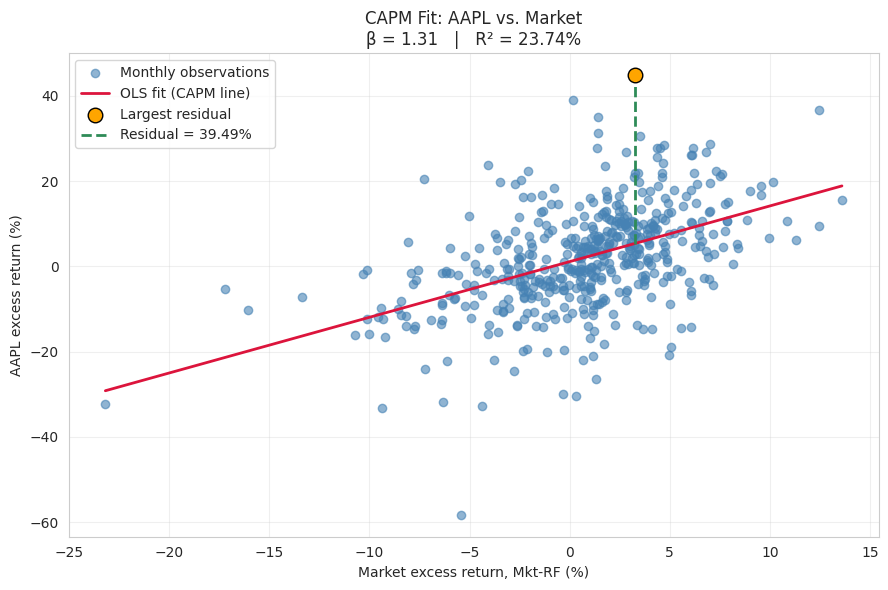

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(merged_clean['Mkt-RF'], merged_clean['AAPL_EXCESS'],
           alpha=0.6, color='steelblue', label='Monthly observations')

x_sorted = np.sort(merged_clean['Mkt-RF'])
y_sorted = capm_model.params['const'] + capm_model.params['Mkt-RF'] * x_sorted
ax.plot(x_sorted, y_sorted, color='crimson', linewidth=2, label='OLS fit (CAPM line)')

# Highlight the observation with the largest positive residual.
worst = merged_clean.loc[merged_clean['Residuals'].idxmax()]
ax.scatter(worst['Mkt-RF'], worst['AAPL_EXCESS'], color='orange', s=110,
           edgecolor='black', zorder=5, label='Largest residual')
ax.vlines(worst['Mkt-RF'], worst['Y_hat'], worst['AAPL_EXCESS'],
          color='seagreen', linestyle='--', linewidth=2,
          label=f"Residual = {worst['Residuals']:.2f}%")

ax.set_xlabel('Market excess return, Mkt-RF (%)')
ax.set_ylabel('AAPL excess return (%)')
ax.set_title(f"CAPM Fit: AAPL vs. Market\n"
             f"β = {capm_model.params['Mkt-RF']:.2f}   |   R² = {capm_model.rsquared:.2%}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 2.** AAPL's excess return plotted on the y-axis against the market's excess return on the x-axis. We overlay the OLS regression line (AAPL's characteristic line in excess-return space) so the reader can visually assess the linear fit and the dispersion of the residuals. Each point is one month, and the vertical distance from a point to the line is that month's residual, i.e., the part of AAPL's return the market factor doesn't explain. The month with the single largest residual is highlighted.

### 8.2 Residuals vs. fitted values

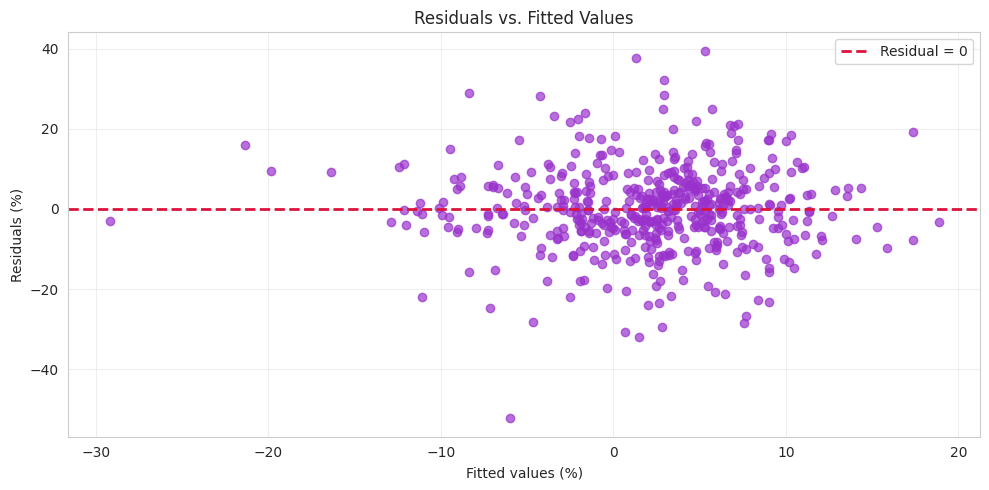

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(merged_clean['Y_hat'], merged_clean['Residuals'], alpha=0.7, color='darkorchid')
ax.axhline(0, color='crimson', linestyle='--', linewidth=2, label='Residual = 0')
ax.set_xlabel('Fitted values (%)')
ax.set_ylabel('Residuals (%)')
ax.set_title('Residuals vs. Fitted Values')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 3.** Residuals plotted against the model's fitted values. If the CAPM's single-factor specification is reasonable for AAPL, these points should scatter randomly around zero, with no funnel shape (non-constant variance) and no curve (nonlinearity). A clear pattern here would undermine the standard errors and p-values reported in Section 6.

### 8.3 Normality of residuals

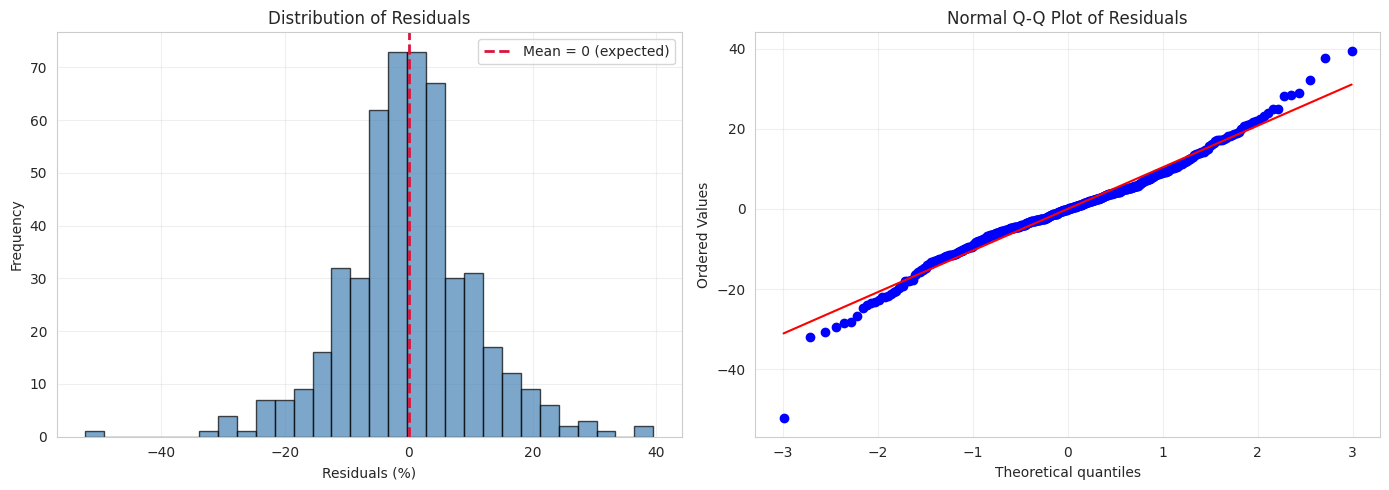

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(merged_clean['Residuals'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(0, color='crimson', linestyle='--', linewidth=2, label='Mean = 0 (expected)')
ax1.set_xlabel('Residuals (%)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Residuals')
ax1.legend()
ax1.grid(alpha=0.3)

stats.probplot(merged_clean['Residuals'], dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot of Residuals')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 4.** Left: histogram of residuals, which should be roughly symmetric and centered on zero. Right: a normal Q-Q plot, comparing residual quantiles to a theoretical normal distribution — points hugging the diagonal support the near-normal-residuals assumption behind the t-tests and p-values in the `.summary()` output above. Heavy tails (points curving away at the ends) are common in monthly stock returns and are worth keeping in mind when trusting the exact p-values.

## 9. Time-Series Stability: Rolling Beta Analysis

A stock's risk profile is rarely static. Business cycles, product launches, and macroeconomic shifts cause market sensitivity to change over time. By computing a rolling beta, we can observe how AAPL's systematic risk has evolved, rather than assuming a single constant beta for its entire history.

The code below utilizes `pandas` to calculate a 60-month rolling beta by computing the rolling covariance between AAPL and the market's excess return, divided by the rolling variance of the market's excess return.

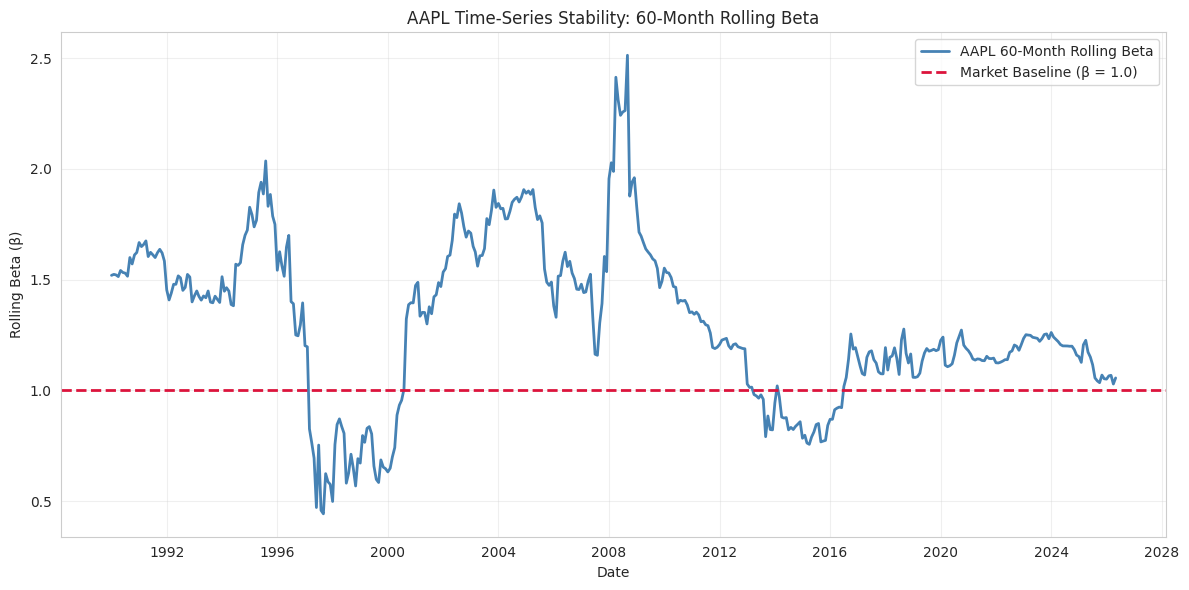

In [ ]:
merged_clean['Date'] = pd.to_datetime(merged_clean['DateStr'])
window = 60

# Compute rolling covariance and rolling variance
rolling_cov = merged_clean['AAPL_EXCESS'].rolling(window=window).cov(merged_clean['Mkt-RF'])
rolling_var = merged_clean['Mkt-RF'].rolling(window=window).var()

# Calculate rolling beta
merged_clean['Rolling_Beta'] = rolling_cov / rolling_var

# Plotting the 60-month rolling beta
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(merged_clean['Date'], merged_clean['Rolling_Beta'], color='steelblue', linewidth=2, label='AAPL 60-Month Rolling Beta')
ax.axhline(1.0, color='crimson', linestyle='--', linewidth=2, label='Market Baseline (β = 1.0)')

ax.set_xlabel('Date')
ax.set_ylabel('Rolling Beta (β)')
ax.set_title('AAPL Time-Series Stability: 60-Month Rolling Beta')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 5**. AAPL 60-Month Rolling Beta. This time-series plot illustrates the evolution of Apple's systematic risk profile over time. The solid blue line tracks AAPL's beta calculated over rolling 60-month windows, while the dashed red line represents the neutral market baseline (β = 1.0). Periods where the rolling beta falls below the baseline (e.g., the late 1990s and 2013–2016) indicate defensive phases where AAPL was historically less volatile than the broader market. Conversely, extended periods well above 1.0 (notably peaking near 2.5 around the 2008 financial crisis) highlight times when the stock acted as a highly aggressive asset, significantly amplifying market movements.

## 10. The CAPM Security Market Line

The regression above estimates AAPL's beta, but the CAPM reference's central visual — the *Security Market Line* — asks a different question: given that beta, what return does CAPM say AAPL *should* earn, and does its actual average return line up? The reference constructs this line with an intercept equal to the risk-free rate and a slope equal to the market's expected excess return (Fig. 2.1), then compares realized returns against it (Fig. 2.2) to see which portfolios "added value" and which fell short.

We reconstruct the same idea from our own sample: using the average `RF` and average `Mkt-RF` as (rough, backward-looking) stand-ins for their expected values, we draw an ex-post Security Market Line, then plot two points for AAPL  where CAPM says it should sit given its estimated β, and where it actually averaged. The vertical gap between the two is, by construction, exactly the α estimated in Section 6.

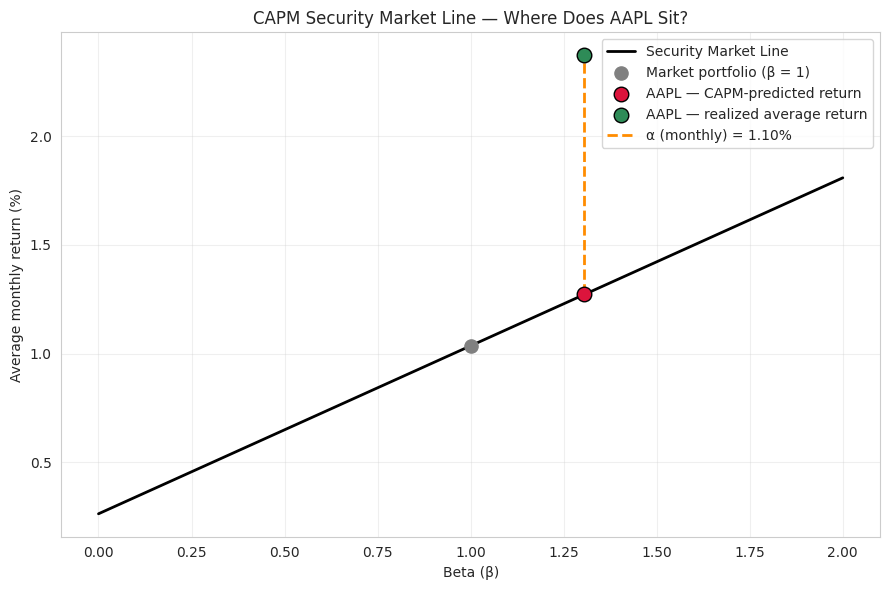

In [ ]:
rf_mean = merged_clean['RF'].mean()
mkt_premium_mean = merged_clean['Mkt-RF'].mean()
beta_aapl = capm_model.params['Mkt-RF']
alpha_aapl = capm_model.params['const']

# Ex-post Security Market Line (sample averages as proxies for expectations):
# E[R] ≈ Rf_bar + beta * Mkt-RF_bar
betas_line = np.linspace(0, 2, 100)
sml_returns = rf_mean + betas_line * mkt_premium_mean

capm_predicted = rf_mean + beta_aapl * mkt_premium_mean   # sits exactly ON the line
realized_avg = merged_clean['Return'].mean()                # AAPL's actual average return

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(betas_line, sml_returns, color='black', linewidth=2, label='Security Market Line')
ax.scatter([1], [rf_mean + mkt_premium_mean], color='gray', s=90, zorder=5,
           label='Market portfolio (β = 1)')
ax.scatter([beta_aapl], [capm_predicted], color='crimson', s=110, edgecolor='black', zorder=5,
           label='AAPL — CAPM-predicted return')
ax.scatter([beta_aapl], [realized_avg], color='seagreen', s=110, edgecolor='black', zorder=5,
           label='AAPL — realized average return')
ax.vlines(beta_aapl, min(capm_predicted, realized_avg), max(capm_predicted, realized_avg),
          color='darkorange', linestyle='--', linewidth=2,
          label=f'α (monthly) = {alpha_aapl:.2f}%')

ax.set_xlabel('Beta (β)')
ax.set_ylabel('Average monthly return (%)')
ax.set_title('CAPM Security Market Line — Where Does AAPL Sit?')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 6.** The black line is an ex-post Security Market Line, built from this sample's average risk-free rate and average market excess return as rough, backward-looking proxies for their expected values. The red point is where CAPM predicts AAPL should sit, given its estimated β; the green point is where AAPL actually averaged over the sample. The dashed gap between them is exactly α from Section 6 — reproducing, with AAPL, the same "did the stock beat its CAPM expectation?" comparison the reference makes in its ex-post market line figure (Fig. 2.2).

## 11. Takeaways & Next Steps

This notebook walked through the full empirical pipeline for a single-factor CAPM regression:

- We collected and aligned two independent monthly data sources, and converted raw returns into the excess returns the CAPM regression actually requires.
- We estimated AAPL's β and α via OLS, and worked through how to read every number in the `statsmodels` summary table.
- We checked the regression's assumptions with residual diagnostics, rather than trusting the p-values blindly.
- We visualized what β and α mean geometrically, by placing AAPL on the Security Market Line.

**Limitations worth keeping in mind:** a single-factor model leaves the complement of R² — often the majority of a stock's monthly variance — unexplained as "idiosyncratic" risk. Beta itself is estimated with sampling error and is known to drift toward 1 over time (the CAPM reference notes this mean-reversion in historical betas, and that fundamentals-based beta forecasts tend to outperform pure historical estimates — Ch. 2). And the CAPM's central claim — that alpha is zero for every asset — is precisely the claim that decades of factor-investing research (size, value, momentum, quality, and beyond) has pushed back on.

**Next steps**, following the roadmap set out in the introduction: re-run this same OLS machinery with additional regressors — the Fama–French three-factor model (`SMB`, `HML`), the Carhart four-factor extension (`MOM`), and the Fama–French five-factor model (`RMW`, `CMA`) — to see how much of AAPL's "alpha" in this notebook gets absorbed once more systematic factors are added.

## References

Fama, E. F., & French, K. R. (1993). Common risk factors in the returns on stocks and bonds. Journal of Financial Economics, 33(1), 3-56.

Lintner, J. (1965). The Valuation of Risk Assets and the Selection of Risky Investments in Stock Portfolios and Capital Budgets. The Review of Economics and Statistics, 47(1), 13-37.

Sharpe, W. F. (1964). Capital Asset Prices: A Theory of Market Equilibrium under Conditions of Risk. The Journal of Finance, 19(3), 425-442.

OpenIntro Statistics, Chapter 7 — Linear Regression with a Single Predictor
Used for regression concepts, including fitting a line, residuals, and the coefficient of determination.

CAPM reference, Chapter 2 — The CAPM
Used for the financial interpretation of regression results, including excess returns, beta, alpha, and the Security Market Line.
